In [21]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
import cv2
from scipy import signal
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree
from scipy import stats
from scipy.stats import t
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [3]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [4]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/0/"
subhalo = get(sub_url)


--------------------------------------------------------------------------------

In [19]:
vis_queries = [
    ("bfieldx", "partField=bfield_x&ctName=viridis&size=20&sizeType=kpc"),
    ("bfieldy", "partField=bfield_y&ctName=viridis&size=20&sizeType=kpc"),
    ("bfieldz", "partField=bfield_z&ctName=viridis&size=20&sizeType=kpc")
]
for i in range(300):
    print("i: ",i)
    for bfield_name, vis_query in vis_queries:
        bfield_url = f"http://www.tng-project.org/api/TNG50-2/snapshots/34/subhalos/{i}/vis.png?{vis_query}"
        try:
            get(bfield_url, out_filename=f'{bfield_name}_sub{i}.png')
        except Exception as e:
            print(f"sub{i} didn't work for {bfield_name}: {e}")

i:  0
i:  1
i:  2
i:  3
i:  4
i:  5
i:  6
i:  7
i:  8
i:  9
i:  10
i:  11
i:  12
i:  13
i:  14
i:  15
i:  16
i:  17
i:  18
i:  19
i:  20
i:  21
i:  22
i:  23
i:  24
i:  25
i:  26
i:  27
i:  28
i:  29
i:  30
i:  31
i:  32
i:  33
i:  34
i:  35
i:  36
i:  37
i:  38
i:  39
i:  40
i:  41
i:  42
i:  43
i:  44
i:  45
i:  46
i:  47
i:  48
i:  49
i:  50
i:  51
i:  52
i:  53
i:  54
i:  55
i:  56
i:  57
i:  58
i:  59
i:  60
i:  61
i:  62
i:  63
i:  64
i:  65
i:  66
i:  67
i:  68
i:  69
i:  70
i:  71
i:  72
i:  73
i:  74
i:  75
i:  76
i:  77
i:  78
i:  79
i:  80
i:  81
i:  82
i:  83
i:  84
i:  85
i:  86
i:  87
i:  88
i:  89
i:  90
i:  91
i:  92
i:  93
i:  94
i:  95
i:  96
i:  97
i:  98
i:  99
i:  100
i:  101
i:  102
i:  103
i:  104
i:  105
i:  106
i:  107
i:  108
i:  109
i:  110
i:  111
i:  112
i:  113
i:  114
i:  115
i:  116
i:  117
i:  118
i:  119
i:  120
i:  121
i:  122
i:  123
i:  124
i:  125
i:  126
i:  127
i:  128
i:  129
i:  130
i:  131
i:  132
i:  133
i:  134
i:  135
i:  136
i:  137
i:  13

In [20]:
min = -6000
max = 7500
bfield_means= []

for i in range(300):
    results = {}
    for bfield in ["bfieldx", "bfieldy", "bfieldz"]:
        img = cv2.imread(f"{bfield}_sub{i}.png")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cbar = img_rgb[100:-100, 1220:-140]
        area = img_rgb[100:-100, 200:1200]

        color = np.mean(cbar, axis=1)
        num = len(color)
        flat = area.reshape(-1,3)
        tree = KDTree(color)
        distances, indices = tree.query(flat)
        estimate = max - (indices/num)*(max-min)
        results[bfield] = estimate.reshape(area.shape[0], area.shape[1])

    bfield_mag = np.sqrt(results["bfieldx"]**2 + results["bfieldy"]**2 + results["bfieldz"]**2)
    mean_bfield = np.mean(bfield_mag)
    bfield_means.append(mean_bfield)

np.savetxt("bfield_means.txt", bfield_means)

In [24]:
sub_path = '/content/drive/MyDrive/sub'

all_bhmdot = []
all_sfr = []

for folder_num in range(100):
    save_file_path = os.path.join(sub_path, f'sb{folder_num}.npz')

    if os.path.exists(save_file_path):
        loaded_data = np.load(save_file_path)
        all_bhmdot.append(loaded_data['bhmdot'])
        all_sfr.append(loaded_data['sfr'])
    else:
        print(f"File not found {folder_num}: {save_file_path}")

if all_bhmdot and all_sfr:
    final_bhmdot = np.concatenate(all_bhmdot)
    final_sfr = np.concatenate(all_sfr)

    print(f"Loaded the data from {len(all_bhmdot)} files.")

    print(f"First 10 elements of final_bhmdot: {final_bhmdot[:10]}")

    print(f"First 10 elements of final_sfr: {final_sfr[:10]}")
else:
    print("No data files were found or loaded.")

Loaded the data from 100 files.
First 10 elements of final_bhmdot: [0.00351652 0.0166792  0.00102882 0.00874955 0.00163583 0.00256499
 0.00037256 0.00249654 0.00077815 0.00277787]
First 10 elements of final_sfr: [410.991     61.4731    19.4075    18.2909     6.63607    7.76953
   0.433356   4.90325    4.00612    1.93112 ]


In [35]:
bhl = 1e4*final_bhmdot[(final_bhmdot != -1) & (final_bhmdot != 0)]
sfrl = final_sfr[(final_sfr != -1) & (final_sfr != 0)].tolist()

bins = np.logspace(-15, 5, 100)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

bh_median = np.median(bhl)
sfr_median = np.median(sfrl)

bh_mean = np.mean(bhl)
sfr_mean = np.mean(sfrl)

bh_std = np.std(bhl)
sfr_std = np.std(sfrl)

counts3, _ = np.histogram(bh_median, bins=bins)
counts4, _ = np.histogram(sfr_median, bins=bins)
counts5, _ = np.histogram(bh_mean, bins=bins)
counts6, _ = np.histogram(sfr_mean, bins=bins)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_505/1293634613.py:1: SyntaxWarning: invalid escape sequence '\d'
  plt.boxplot([bhl, sfrl, bfield_means[:100]], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$', '$b_{mag}$'])
/tmp/ipykernel_505/1293634613.py:1: SyntaxWarning: invalid escape sequence '\d'
  plt.boxplot([bhl, sfrl, bfield_means[:100]], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$', '$b_{mag}$'])
/tmp/ipykernel_505/1293634613.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bhl, sfrl, bfield_means[:100]], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$', '$b_{mag}$'])


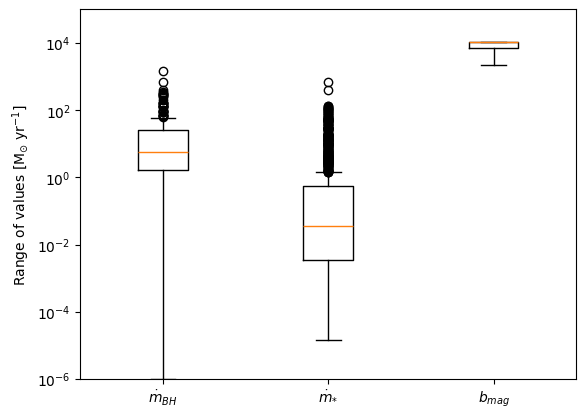

In [38]:
plt.boxplot([bhl, sfrl, bfield_means[:100]], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$', '$b_{mag}$'])
plt.ylabel(r'Range of values [$\mathrm{M}_{\odot}$ $\mathrm{yr}^{-1}$]')
plt.yscale('log')
plt.ylim(10e-7, 10e4)
plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_505/89764323.py:1: SyntaxWarning: invalid escape sequence '\d'
  plt.boxplot([bhl, sfrl], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$'])
/tmp/ipykernel_505/89764323.py:1: SyntaxWarning: invalid escape sequence '\d'
  plt.boxplot([bhl, sfrl], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$'])
/tmp/ipykernel_505/89764323.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bhl, sfrl], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$'])


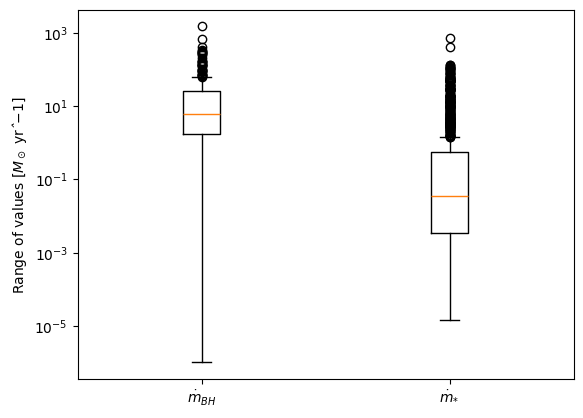

In [39]:
plt.boxplot([bhl, sfrl], labels=['$\dot{m}_{BH}$', '$\dot{m}_{*}$'])
#plt.title('Log boxplot of bhmdot and sfr')
plt.ylabel(r'Range of values [$M_\odot$ yr$ˆ{-1}$]' )
plt.yscale('log')
#plt.xscale('log')
plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_505/1525033717.py:1: SyntaxWarning: invalid escape sequence '\d'
  plt.hist(bhl, bins=bins, alpha=0.5, label='$\dot{m}_{BH}$', color='blue', density=True)
/tmp/ipykernel_505/1525033717.py:2: SyntaxWarning: invalid escape sequence '\d'
  plt.hist(sfrl, bins=bins, alpha=0.5, label='$\

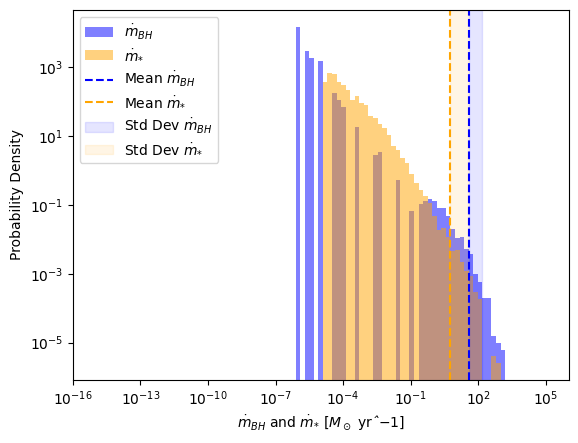

In [40]:
plt.hist(bhl, bins=bins, alpha=0.5, label='$\dot{m}_{BH}$', color='blue', density=True)
plt.hist(sfrl, bins=bins, alpha=0.5, label='$\dot{m}_{*}$', color='orange', density=True)

plt.axvline(bh_mean, color='blue', linestyle='--', label='Mean $\dot{m}_{BH}$')
plt.axvline(sfr_mean, color='orange', linestyle='--', label='Mean $\dot{m}_{*}$')

plt.axvspan(bh_mean , bh_mean + bh_std, alpha=0.1, color='blue', label='Std Dev $\dot{m}_{BH}$')
plt.axvspan(sfr_mean , sfr_mean + sfr_std, alpha=0.1, color='orange', label='Std Dev $\dot{m}_{*}$')


#plt.title('Histogram of bhmdot and sfr')
plt.xlabel('$\dot{m}_{BH}$ and $\dot{m}_{*}$ [$M_\odot$ yr$ˆ{-1}$]')
plt.ylabel('Probability Density')

plt.yscale('log')
plt.xscale('log')
plt.legend()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_505/833438320.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.hist(bhl, bins=bins, alpha=0.5, label='$\dot{m}_{BH}$', color='blue', density=True)
/tmp/ipykernel_505/833438320.py:5: SyntaxWarning: invalid escape sequence '\d'
  plt.hist(sfrl, bins=bins, alpha=0.5, label='

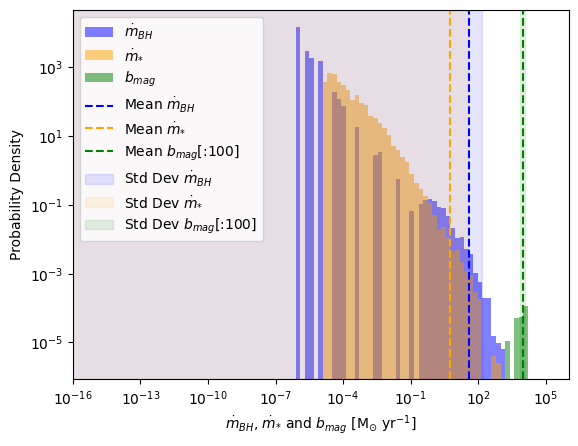

In [41]:
bfield_mean_100 = np.mean(bfield_means[:100])
bfield_std_100 = np.std(bfield_means[:100])

plt.hist(bhl, bins=bins, alpha=0.5, label='$\dot{m}_{BH}$', color='blue', density=True)
plt.hist(sfrl, bins=bins, alpha=0.5, label='$\dot{m}_{*}$', color='orange', density=True)
plt.hist(bfield_means[:100], bins=bins, alpha=0.5, label='$b_{mag}$', color='green', density=True)

plt.axvline(bh_mean, color='blue', linestyle='--', label='Mean $\dot{m}_{BH}$')
plt.axvline(sfr_mean, color='orange', linestyle='--', label='Mean $\dot{m}_{*}$')
plt.axvline(bfield_mean_100, color='green', linestyle='--', label='Mean $b_{mag}$[:100]')

plt.axvspan(bh_mean - bh_std, bh_mean + bh_std, alpha=0.1, color='blue', label='Std Dev $\dot{m}_{BH}$')
plt.axvspan(sfr_mean - sfr_std, sfr_mean + sfr_std, alpha=0.1, color='orange', label='Std Dev $\dot{m}_{*}$')
plt.axvspan(bfield_mean_100 - bfield_std_100, bfield_mean_100 + bfield_std_100, alpha=0.1, color='green', label='Std Dev $b_{mag}$[:100]')

#plt.title('Histogram of bhmdot, sfr, and bmag')
plt.xlabel('$\dot{m}_{BH}$, $\dot{m}_{*}$ and $b_{mag}$ [M$_{\odot}$ yr$^{-1}$]')
plt.ylabel('Probability Density')

plt.yscale('log')
plt.xscale('log')
plt.legend()

In [42]:
t_stat, p_val = stats.ttest_ind(bhl, sfrl)

print(f"t_stat: {t_stat: .2f}")
print(f"p-val: {p_val: .3f}")

alpha = 0.05
if p_val < alpha:
    print(f"Since p-value ({p_val: .3f} is < than alpha ({alpha})), we reject the null hypothesis")
elif p_val > alpha:
    print(f"Since p-value ({p_val: .3f} is > than alpha ({alpha})), we accept the null hypothesis")

t_stat:  8.15
p-val:  0.000
Since p-value ( 0.000 is < than alpha (0.05)), we reject the null hypothesis


In [44]:
t_stat, p_val = stats.ttest_ind(bfield_means[:100], sfrl)

print(f"t_stat: {t_stat: .2f}")
print(f"p-val: {p_val: .3f}")

alpha = 0.05
if p_val < alpha:
    print(f"Since p-value ({p_val: .3f} is < than alpha ({alpha})), we reject the null hypothesis")
elif p_val > alpha:
    print(f"Since p-value ({p_val: .3f} is > than alpha ({alpha})), we accept the null hypothesis")

t_stat:  147.49
p-val:  0.000
Since p-value ( 0.000 is < than alpha (0.05)), we reject the null hypothesis


In [43]:
t_stat, p_val = stats.ttest_ind(bhl, bfield_means[:100])

print(f"t_stat: {t_stat: .2f}")
print(f"p-val: {p_val: .3f}")

alpha = 0.05
if p_val < alpha:
    print(f"Since p-value ({p_val: .3f} is < than alpha ({alpha})), we reject the null hypothesis")
elif p_val > alpha:
    print(f"Since p-value ({p_val: .3f} is > than alpha ({alpha})), we accept the null hypothesis")

t_stat: -74.92
p-val:  0.000
Since p-value ( 0.000 is < than alpha (0.05)), we reject the null hypothesis
